In [1]:
from math import sqrt

import numpy as np
import pandas as pd

# pysheds 0.5 calls np.in1d which was removed in NumPy 2.0
if not hasattr(np, "in1d"):
    np.in1d = lambda ar1, ar2, **kw: np.isin(ar1, ar2, **kw).ravel()

from pysheds.grid import Grid
import matplotlib.pyplot as plt
import matplotlib.colors as colors

DEM_PATH = "../autoates_v2/test-data/Bow Summit/dem.tif"

# D8 (Deterministic-8) Flow

- This relies on the GIS principle that water flows downstream
- The D stands for direction and 8 is the number of cells included in the calculation
- The idea is that the water will flow to its steepest neighbour
- 
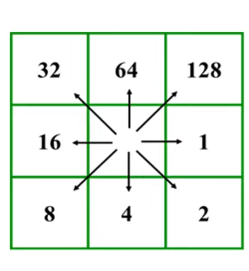


### Formula

$ S = \frac{\Delta z}{d} $

- $S$: slope
- $\Delta z$: difference in elevation
- $d$: distance between cell centres
  - 1 for N, S, E and W
  - $\sqrt 2$ for diagonals

### Basic Example

Each number is in metres and the index can be interpreted as coordinates. 

- `dem[0][:3]` will be abc
- `dem[1][:3]` will be def
- `dem[2][:3]` will be fgh

In [2]:
dem = np.array([
    [67, 56, 49],
    [53, 22, 37],
    [58, 55, 16]                
])
dem

array([[67, 56, 49],
       [53, 22, 37],
       [58, 55, 16]])

In [3]:
s_eh = (22 - 16) / sqrt((1 ** 2) + (1 ** 2)) # 22, 16
s_eh

4.242640687119285

In [4]:
def calculate_d8(array: np.ndarray, x1: int, y1: int, x2: int, y2: int) -> np.float64:
    z1 = array[x1][y1]
    z2 = array[x2][y2]
    delta_z = max(z1, z2) - min(z1, z2)
    d = 1
    # Set distance to sqrt(2) if diagonal
    if x1 != x2 or y1 != y2:
        d = sqrt((1**2) + (1**2))
    return delta_z / d


calculate_d8(dem, 1, 1, 2, 2)

np.float64(4.242640687119285)

## Practical Pysheds Example


### 1. Load DEM + PRA

Load the elevation model and the binary Potential Release Area (PRA) raster together. The PRA marks cells with release-zone slope angles (~30–60°) — it will be used as accumulation weights later.

DEM shape : (242, 218),  cell size: 25.7 m
PRA shape : (242, 218)
Release cells: 7,131  (13.5% of area)


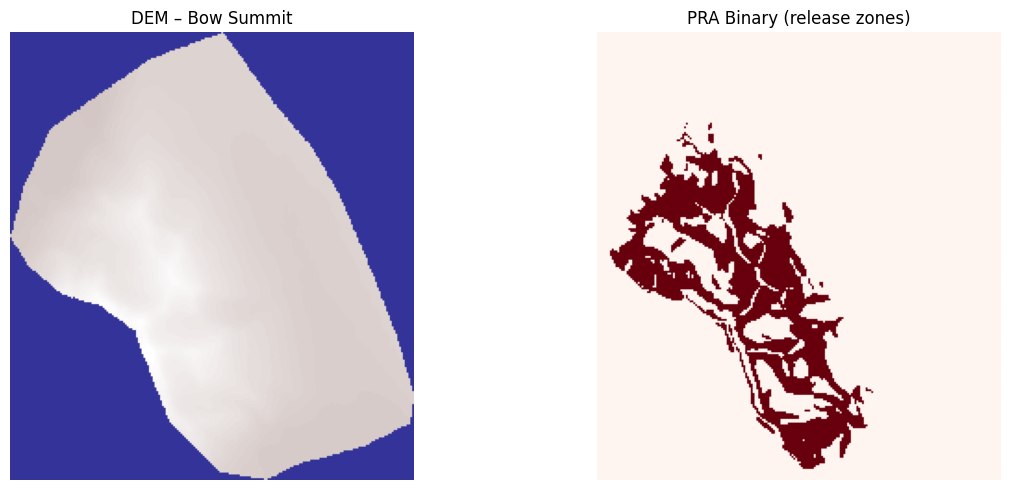

In [18]:
DEM_PATH = "../autoates_v2/test-data/Bow Summit/dem.tif"
PRA_PATH = "../autoates_v2/test-data/Bow Summit/pra_binary.tif"

grid = Grid.from_raster(DEM_PATH)
dem = grid.read_raster(DEM_PATH)
pra = grid.read_raster(PRA_PATH)

print(f"DEM shape : {dem.shape},  cell size: {abs(grid.affine.a):.1f} m")
print(f"PRA shape : {pra.shape}")
print(f"Release cells: {int(pra.sum()):,}  ({100 * pra.mean():.1f}% of area)")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].imshow(dem, cmap="terrain")
axes[0].set_title("DEM – Bow Summit")
axes[0].axis("off")
axes[1].imshow(pra, cmap="Reds")
axes[1].set_title("PRA Binary (release zones)")
axes[1].axis("off")
plt.tight_layout()
plt.show()

In [19]:
dem

Raster([[-9999, -9999, -9999, ..., -9999, -9999, -9999],
        [-9999, -9999, -9999, ..., -9999, -9999, -9999],
        [-9999, -9999, -9999, ..., -9999, -9999, -9999],
        ...,
        [-9999, -9999, -9999, ..., -9999, -9999, -9999],
        [-9999, -9999, -9999, ..., -9999, -9999, -9999],
        [-9999, -9999, -9999, ..., -9999, -9999, -9999]],
       shape=(242, 218), dtype=int16)

### 2. Minimal DEM Conditioning

For avalanche routing we only fix single-cell pits (DEM artefacts). We deliberately skip `fill_depressions` and `resolve_flats` — those steps flatten bowls and cirques that are real avalanche terrain features and would corrupt the slope angles used by PRA.

In [14]:
dem_conditioned = grid.fill_pits(dem)

diff = np.array(dem_conditioned) - np.array(dem)
print(f"Single-cell pits filled: {(diff != 0).sum():,}")

Single-cell pits filled: 12


### 3. D8 Flow Direction

Compute the steepest-descent direction for every cell. This tells us where material (snow) leaving any cell would travel next.

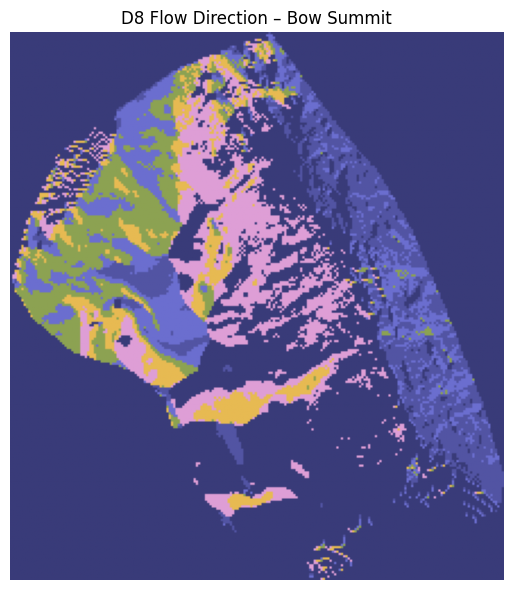

In [15]:
DIRMAP = (64, 128, 1, 2, 4, 8, 16, 32)  # E, NE, N, NW, W, SW, S, SE

fdir = grid.flowdir(dem_conditioned, dirmap=DIRMAP)

plt.figure(figsize=(7, 6))
plt.imshow(fdir, cmap="tab20b")
plt.title("D8 Flow Direction – Bow Summit")
plt.axis("off")
plt.tight_layout()
plt.show()

### 4. PRA-Weighted Accumulation → Avalanche Exposure

Instead of counting all upstream cells (hydrology), we weight the accumulation by the PRA binary raster. Each cell's value becomes:

> **number of release-area cells that drain through it**

High values mean many potential avalanche paths converge there — a direct terrain exposure signal used in ATES classification.

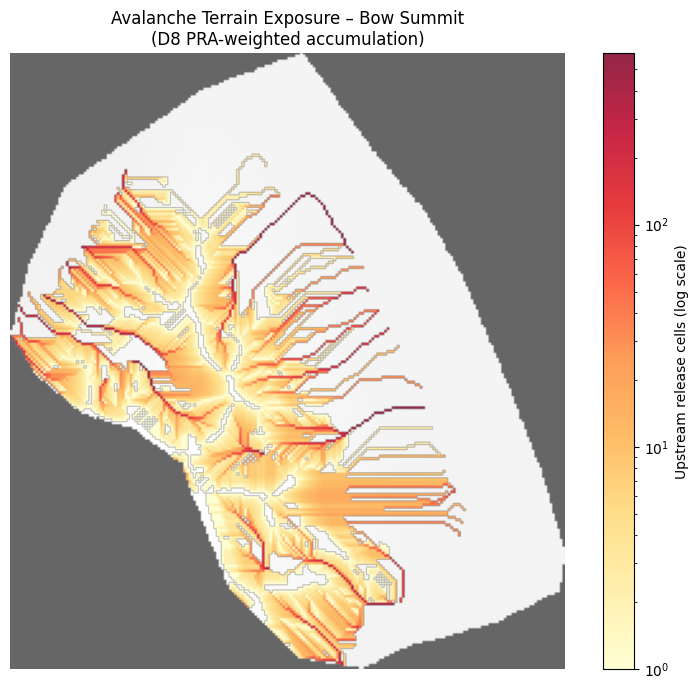

Max exposure : 591 release cells converging


In [16]:
exposure = grid.accumulation(fdir, weights=pra, dirmap=DIRMAP)

# Mask zero-exposure cells so the DEM hillshade shows through
exposure_masked = np.where(exposure > 0, exposure, np.nan)

fig, ax = plt.subplots(figsize=(8, 7))
ax.imshow(dem, cmap="gray", alpha=0.6)
im = ax.imshow(
    exposure_masked,
    norm=colors.LogNorm(vmin=1, vmax=np.nanmax(exposure_masked)),
    cmap="YlOrRd",
    alpha=0.85,
)
plt.colorbar(im, ax=ax, label="Upstream release cells (log scale)")
ax.set_title("Avalanche Terrain Exposure – Bow Summit\n(D8 PRA-weighted accumulation)")
ax.axis("off")
plt.tight_layout()
plt.show()

print(f"Max exposure : {int(exposure.max()):,} release cells converging")

                     FlowPy=0   FlowPy=1
D8=0                   16,022      2,955   (FN: D8 misses FlowPy paths)
D8=1                    1,105     11,036   (FP: D8 overestimates)

Precision : 0.909  (of D8-positive cells, how many FlowPy agrees)
Recall    : 0.789  (of FlowPy paths, how many D8 catches)
F1        : 0.845


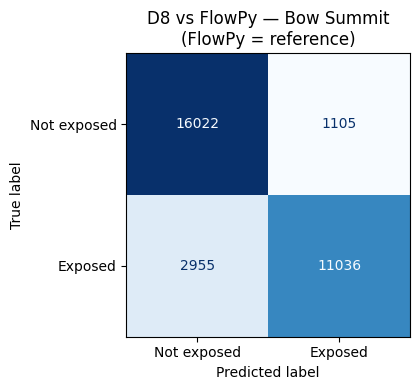

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Flatten valid (non-nodata) cells only
valid = (np.array(dem) != dem.nodata).ravel()

y_true = (np.array(fp_counts).ravel() > 0)[valid].astype(int)   # FlowPy = reference
y_pred = (np.array(exposure).ravel() > 0)[valid].astype(int)     # D8     = prediction

cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

total = tn + fp + fn + tp
print(f"{'':20s} FlowPy=0   FlowPy=1")
print(f"{'D8=0':20s} {tn:>8,}   {fn:>8,}   (FN: D8 misses FlowPy paths)")
print(f"{'D8=1':20s} {fp:>8,}   {tp:>8,}   (FP: D8 overestimates)")
print(f"\nPrecision : {tp / (tp + fp):.3f}  (of D8-positive cells, how many FlowPy agrees)")
print(f"Recall    : {tp / (tp + fn):.3f}  (of FlowPy paths, how many D8 catches)")
print(f"F1        : {2*tp / (2*tp + fp + fn):.3f}")

disp = ConfusionMatrixDisplay(cm, display_labels=["Not exposed", "Exposed"])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("D8 vs FlowPy — Bow Summit\n(FlowPy = reference)")
plt.tight_layout()
plt.show()